# Clase 8 - Unidad 3
Aplicaciones Computacionales en Ing.

* Franco Mansilla Ibáñez (www.francomansilla.com)

In [1]:
import pandas as pd
import numpy as np

In [2]:
dir = "/Users/francomansilla/Library/CloudStorage/GoogleDrive.com/Mi unidad/universidad mayor/Aplicaciones Computacionales/Clase 8"

In [3]:
file_path = dir + "/BD_tratada.xlsx"

# Leer el archivo Excel
df = pd.read_excel(file_path)

In [4]:
df.head()

,make,price,mpg,rep78,weight,length,foreign,mpg_tramos
0,AMC Concord,4099.0,22,3.0,2930,186,Domestic,Alto
1,AMC Pacer,4749.0,17,3.0,3350,173,Domestic,Bajo
2,AMC Spirit,3799.0,22,NaN,2640,168,Domestic,Alto
3,Buick Century,4816.0,20,3.0,3250,196,Domestic,Bajo
4,Buick Electra,7827.0,15,4.0,4080,222,Domestic,Bajo


# 1. Tratamiento de Missing Value

* **Paso 1.** Identificación de Missing Value 

In [5]:
df.isnull()

,make,price,mpg,rep78,weight,length,foreign,mpg_tramos
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
69,False,False,False,False,False,False,False,False
70,False,False,False,False,False,False,False,False
71,False,False,False,False,False,False,False,False
72,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

make          0
price         0
mpg           0
rep78         5
weight        0
length        0
foreign       0
mpg_tramos    2
dtype: int64

In [7]:
df.isnull().sum().to_dict()

{'make': 0,
 'price': 0,
 'mpg': 0,
 'rep78': 5,
 'weight': 0,
 'length': 0,
 'foreign': 0,
 'mpg_tramos': 2}

In [8]:
def missing_value(df):
    """
    Función para obtener un diccionario con la cantidad de valores faltantes por cada columna en un DataFrame.

    Parameters:
    df (pandas.DataFrame): El DataFrame para el cual se quiere obtener el conteo de valores faltantes.

    Returns:
    dict: Un diccionario donde las claves son los nombres de las columnas y los valores son la cantidad de valores faltantes.
    """
    missing_dict = df.isnull().sum().to_dict()
    return missing_dict

In [9]:
# Ejemplo de uso:
missing_values = missing_value(df)
missing_values

{'make': 0,
 'price': 0,
 'mpg': 0,
 'rep78': 5,
 'weight': 0,
 'length': 0,
 'foreign': 0,
 'mpg_tramos': 2}

* **Paso 2.** Tratamiento de Missing Value

In [10]:
def replace_missing_values(df):
    """
    Función para reemplazar valores faltantes en un DataFrame según reglas específicas:
    - Si una columna numérica tiene más de 5 valores únicos, reemplaza los valores faltantes con la media.
    - Si una columna numérica tiene menos de 5 valores únicos, reemplaza los valores faltantes con el máximo valor + 1.
    - Guarda en un diccionario el número de valores faltantes reemplazados por columna.

    Parameters:
    df (pandas.DataFrame): El DataFrame para el cual se quieren reemplazar los valores faltantes.

    Returns:
    pandas.DataFrame: El DataFrame con los valores faltantes reemplazados.
    dict: Un diccionario donde las claves son los nombres de las columnas y los valores son la cantidad de valores reemplazados.
    """
    df_copy = df.copy()
    
    var_tratadas = {}

    numeric_columns = df.select_dtypes(include=[np.number]).columns

    for column in numeric_columns:
        num_unicos = df_copy[column].nunique()
        num_missing = df_copy[column].isnull().sum()

        if num_missing > 0:
            if num_unicos > 5:
                valor_tratado = df[column].mean()
                df[column].fillna(valor_tratado, inplace=True)
                
            elif num_unicos <= 5:
                valor_tratado = df[column].max() + 1
                df[column].fillna(valor_tratado, inplace=True)
            
            var_tratadas[column] = num_missing

    return df, var_tratadas

In [11]:
df, replaced_values = replace_missing_values(df)
replaced_values

{'rep78': 5}

In [12]:
df.isnull().sum()

make          0
price         0
mpg           0
rep78         0
weight        0
length        0
foreign       0
mpg_tramos    2
dtype: int64

--- 

# 2. Gráficos

En el análisis de datos, los gráficos son herramientas esenciales para visualizar información, identificar patrones y comunicar hallazgos de manera efectiva. A continuación, se presenta una introducción a algunos de los gráficos más comunes y su uso en el análisis de datos.

Aquí tienes una lista de los gráficos más usados en el análisis de datos, junto con una breve descripción de cada uno:

1. **Gráfico de Barras**: Utilizado para comparar cantidades entre diferentes categorías.
2. **Gráfico de Líneas**: Ideal para visualizar tendencias a lo largo del tiempo.
3. **Gráfico de Dispersión (Scatter Plot)**: Muestra la relación entre dos variables numéricas.
4. **Histograma**: Visualiza la distribución de una variable continua.
5. **Gráfico de Caja y Bigotes (Boxplot)**: Muestra la distribución de un conjunto de datos, resaltando la mediana, cuartiles y valores atípicos.
6. **Gráfico Circular (Pie Chart)**: Utilizado para mostrar proporciones de un todo.
7. **Gráfico de Áreas**: Similar al gráfico de líneas, pero las áreas bajo las líneas están rellenas.
8. **Gráfico de Barras Apiladas**: Muestra la composición de categorías dentro de una barra total.
9. **Gráfico de Densidad**: Similar a un histograma, pero utiliza una curva suave para mostrar la distribución de los datos.
10. **Gráfico de Mapa de Calor (Heatmap)**: Muestra valores en una matriz coloreada, ideal para visualizar la intensidad de datos a lo largo de dos dimensiones.
11. **Gráfico de Violin (Violin Plot)**: Combina el gráfico de caja y bigotes con una estimación de densidad de kernel, mostrando la distribución de los datos.
12. **Gráfico de Burbuja (Bubble Chart)**: Similar al gráfico de dispersión, pero cada punto incluye una tercera dimensión a través del tamaño de la burbuja.
13. **Gráfico de Series Temporales**: Muestra datos recolectados a intervalos de tiempo regulares, útil para analizar patrones y tendencias temporales.
14. **Gráfico de Pares (Pair Plot)**: Muestra las relaciones entre múltiples variables numéricas en forma de matriz de gráficos de dispersión.
15. **Gráfico de Radial o Araña (Spider Chart)**: Utilizado para mostrar variables multivariantes en un gráfico radial.


---

## 2.1.  Histogramas

#### ¿Qué es un Histograma?

Un histograma es un tipo de gráfico que se utiliza para representar la distribución de una variable continua dividiéndola en intervalos (también llamados "bins") y mostrando la frecuencia de los datos que caen en cada intervalo. Cada barra en un histograma representa un intervalo y la altura de la barra indica la cantidad de datos que se encuentran dentro de ese intervalo.

#### Parámetros Necesarios

Para crear un histograma, generalmente se necesitan los siguientes parámetros:
- **Datos**: Los valores de la variable continua que se desea analizar.
- **Bins (Intervalos)**: El número de intervalos en los que se dividen los datos. Esto puede determinarse automáticamente o especificarse manualmente.
- **Rango**: El rango de valores que se quiere incluir en el histograma (opcional).

#### ¿Para Qué se Usa?

Los histogramas son útiles para:
- Visualizar la distribución de los datos.
- Identificar la forma de la distribución (por ejemplo, si es normal, sesgada, etc.).
- Detectar la presencia de valores atípicos.
- Comprender la dispersión y la concentración de los datos.
---

* Supongamos que tenemos un DataFrame llamado `df` que contiene información sobre vehículos. Queremos crear un histograma para visualizar la distribución del precio de los vehículos. A continuación, se muestra cómo hacerlo.

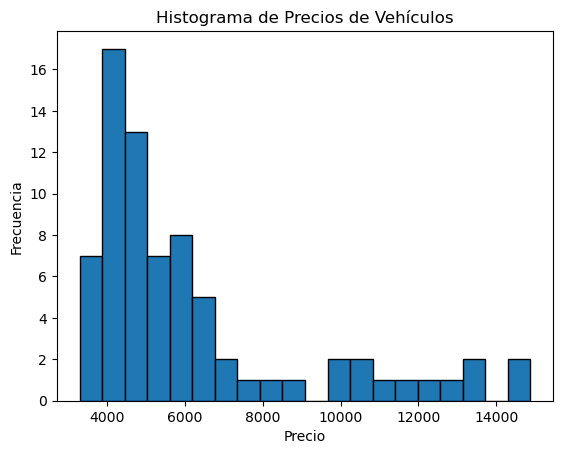

In [13]:
import matplotlib.pyplot as plt

# Crear histograma del precio de los vehículos
plt.hist(df['price'], bins=20, edgecolor='black')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Histograma de Precios de Vehículos')
plt.show()


---

## 2.2.  Gráfico de Torta

#### ¿Qué es un Gráfico de Torta?

Un gráfico de torta, también conocido como gráfico circular, es un tipo de gráfico que muestra la proporción de diferentes categorías dentro de un conjunto de datos. Cada sector del gráfico representa una categoría, y el tamaño de cada sector es proporcional a la frecuencia o cantidad de esa categoría en el conjunto de datos.

#### Parámetros Necesarios

Para crear un gráfico de torta, se necesitan los siguientes parámetros:
- **Datos**: Las cantidades o frecuencias de cada categoría.
- **Etiquetas**: Las categorías correspondientes a cada sector del gráfico.

#### ¿Para Qué se Usa?

El gráfico de torta es útil para:
- Visualizar la proporción de cada categoría respecto al total.
- Comparar la contribución de cada categoría.
- Representar datos categóricos de manera intuitiva y visual.

---

Supongamos que tenemos un DataFrame llamado `df` que contiene información sobre vehículos. Queremos crear un gráfico de torta para visualizar la distribución de la variable `rep78`, que representa la calidad del repuesto de los vehículos en una escala de 1 a 5. A continuación, se muestra cómo hacerlo.

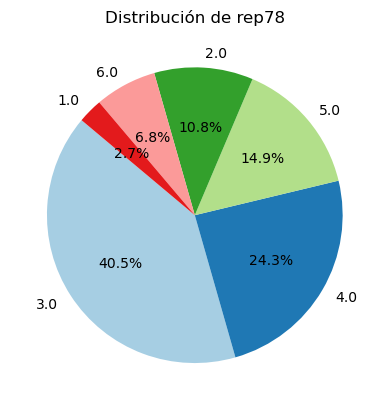

In [14]:
# Eliminar valores NaN en rep78 para el gráfico de torta
rep78_counts = df['rep78'].value_counts()

# Crear gráfico de torta
plt.pie(rep78_counts, labels=rep78_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(np.arange(len(rep78_counts))))
plt.title('Distribución de rep78')
plt.show()


## 2.3. Gráfico de Dispersión (Scatter Plot)

#### ¿Qué es un Gráfico de Dispersión?

Un gráfico de dispersión (scatter plot) es un tipo de gráfico que se utiliza para visualizar la relación entre dos variables numéricas. Cada punto en el gráfico representa una observación en el conjunto de datos, con su posición determinada por los valores de las dos variables correspondientes. El gráfico de dispersión es ideal para identificar relaciones, patrones y posibles correlaciones entre las variables.

#### Parámetros Necesarios

Para crear un gráfico de dispersión, se necesitan los siguientes parámetros:
- **Eje X**: Los valores de la primera variable.
- **Eje Y**: Los valores de la segunda variable.
- **Color (opcional)**: Puede utilizarse para distinguir diferentes categorías o grupos dentro de los datos.
- **Tamaño (opcional)**: Puede variar para representar otra dimensión de los datos.

#### ¿Para Qué se Usa?

El gráfico de dispersión es útil para:
- Visualizar la relación entre dos variables.
- Identificar patrones, tendencias y posibles correlaciones.
- Detectar valores atípicos o outliers.
- Comparar la distribución de diferentes grupos o categorías.

Supongamos que tenemos un DataFrame llamado `df` que contiene información sobre vehículos. Queremos crear un gráfico de dispersión para visualizar la relación entre el precio (`price`) y el consumo de combustible (`mpg`) de los vehículos. A continuación, se muestra cómo hacerlo.


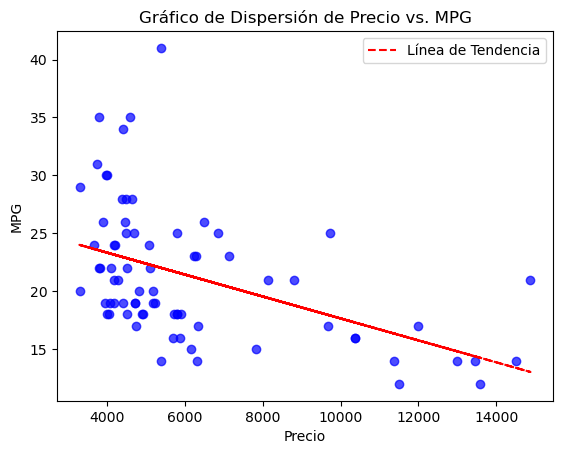

In [15]:
# Crear gráfico de dispersión
plt.scatter(df['price'], df['mpg'], color='blue', alpha=0.7)

# Añadir etiquetas y título
plt.xlabel('Precio')
plt.ylabel('MPG')
plt.title('Gráfico de Dispersión de Precio vs. MPG')

# Añadir línea de tendencia
z = np.polyfit(df['price'], df['mpg'], 1)
p = np.poly1d(z)
plt.plot(df['price'], p(df['price']), "r--", label='Línea de Tendencia')

# Añadir leyenda
plt.legend()

# Mostrar gráfico
plt.show()

--- 

## 2.4. Introducción a Subplots

#### ¿Qué es un Subplot?

Un subplot es una técnica en la visualización de datos que permite crear múltiples gráficos en una sola figura. Esto es útil para comparar diferentes visualizaciones de datos en el mismo contexto, mostrando diferentes aspectos de los datos en paralelo.

#### Parámetros Necesarios

Para crear subplots, generalmente se necesitan los siguientes parámetros:
- **Número de Filas y Columnas**: Define la disposición de los gráficos en la figura.
- **Índice del Subplot**: Especifica la posición de un gráfico en la figura.
- **Compartir Ejes (opcional)**: Permite compartir los ejes entre diferentes subplots para una comparación más fácil.

#### ¿Para Qué se Usa?

Los subplots son útiles para:
- Comparar diferentes visualizaciones de datos en una sola figura.
- Mostrar múltiples vistas de los mismos datos.
- Organizar gráficos de manera compacta y coherente.

---


Supongamos que tenemos un DataFrame llamado `df` que contiene información sobre vehículos. Queremos crear una figura que combine un gráfico de dispersión (`scatter plot`) de `price` vs. `mpg` y un histograma de `price`. A continuación, se muestra cómo hacerlo.


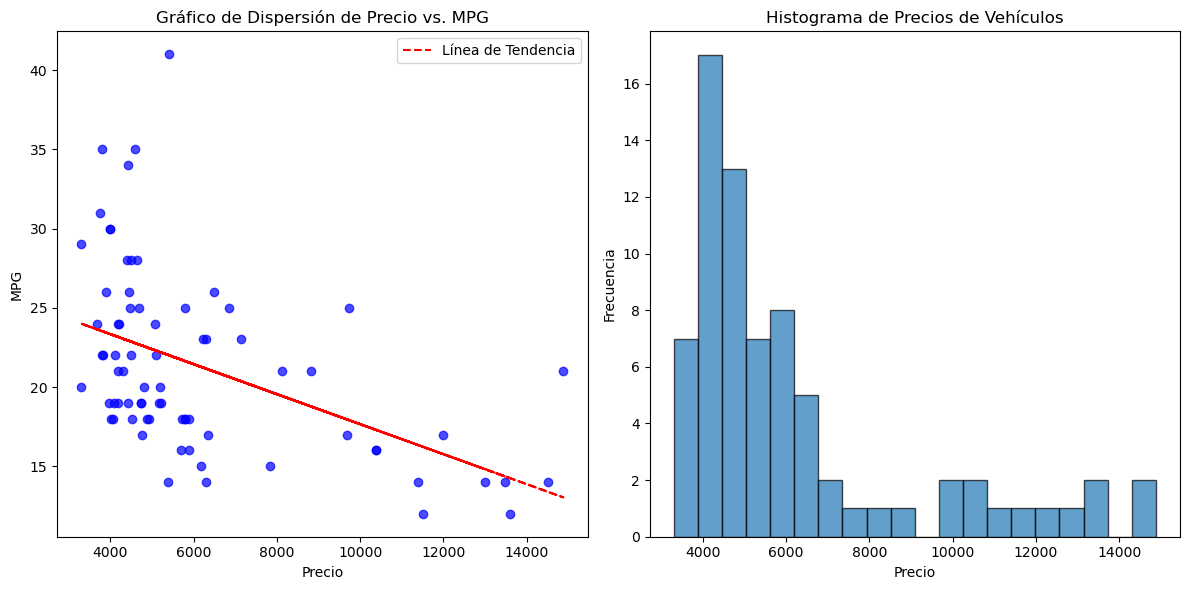

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de dispersión
ax1.scatter(df['price'], df['mpg'], color='blue', alpha=0.7)
ax1.set_xlabel('Precio')
ax1.set_ylabel('MPG')
ax1.set_title('Gráfico de Dispersión de Precio vs. MPG')

# Añadir línea de tendencia al gráfico de dispersión
z = np.polyfit(df['price'], df['mpg'], 1)
p = np.poly1d(z)
ax1.plot(df['price'], p(df['price']), "r--", label='Línea de Tendencia')
ax1.legend()

# Histograma del precio
ax2.hist(df['price'], bins=20, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Precio')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Histograma de Precios de Vehículos')

# Mostrar gráficos
plt.tight_layout()
plt.show()